## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ifood.model import LGBMTrainer
from ifood.model import LGBMHyperparameterOptimizer
from optuna.visualization import plot_optimization_history, plot_param_importances as plot_param_importance
import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
sns.set_theme()

/Users/vho/dev/entrevistas/ifood-case/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Train

### Not causal model (using only customer information)

In [ ]:
features = [
    # Customer
    "age",
    "credit_card_limit",
    "account_age",
    # "gender" removed for fairness 
]

default_params = {
    "n_estimators": 100,
    "learning_rate": 0.05,
    "verbose": -1,
}

trainer = LGBMTrainer(
    data_path = str(Path.cwd().parent / 'data' / 'processed'/ 'unified'),
    random_state=42,
    target='target',
    features=features,
    categorical_features=['offer_type'],
    lgbm_params=default_params
)
X_train, X_test, y_train, y_test = trainer.prepare_data()
not_causal_model, metrics = trainer.train()

metrics

,train,test
rmse,55.746081,58.720261
r2,0.186054,0.056662
spearman_correlation,0.588777,0.536042


### Baseline for hp tuning

In [ ]:
features = [
    # Offer Params
    "time_since_test_start",
    "discount_value",
    "duration",
    "min_value",
    "offer_type",
    "web_channel",
    "mobile_channel",
    "email_channel",
    "social_channel",
    # Customer
    "age",
    "credit_card_limit",
    "account_age",
    # "gender" removed for fairness 
]

default_params = {
    "n_estimators": 100,
    "learning_rate": 0.05,
    "verbose": -1,
}

trainer = LGBMTrainer(
    data_path = str(Path.cwd().parent / 'data' / 'processed'/ 'unified'),
    random_state=42,
    target='target',
    features=features,
    categorical_features=['offer_type'],
    lgbm_params=default_params
)
X_train, X_test, y_train, y_test = trainer.prepare_data()
model, metrics = trainer.train()

metrics

,train,test
rmse,53.482757,57.744080
r2,0.250805,0.087766
spearman_correlation,0.670660,0.631754


### Optimize with Optuna

In [5]:
optimizer = LGBMHyperparameterOptimizer(trainer, n_trials=30)
study = optimizer.optimize()

In [6]:
print(f'Best RMSE (CV): {study.best_value:.4f}')
print("Best hyperparameters:")
print(json.dumps(study.best_params, indent=2))

Best RMSE (CV): 58.6760
Best hyperparameters:
{
  "n_estimators": 183,
  "learning_rate": 0.0215290052320779,
  "num_leaves": 107,
  "max_depth": 3,
  "min_child_samples": 90,
  "subsample": 0.7983055211842092,
  "colsample_bytree": 0.9947602430815886,
  "reg_alpha": 4.2312459884682965e-05,
  "reg_lambda": 1.894221488898317
}


In [7]:
plot_optimization_history(study)

In [17]:
fig = plot_param_importance(study)
fig.update_layout(
    width=400,
    height=400
)

### Optimized

In [ ]:
treatment = [
    # Offer Params
    "time_since_test_start",
    "discount_value",
    "duration",
    "min_value",
    "offer_type",
    "web_channel",
    "mobile_channel",
    "email_channel",
    "social_channel",
]

features = treatment + [
    # Customer
    "age",
    "credit_card_limit",
    "account_age",
    # "gender" removed for fairness 
]

default_params = {
    "n_estimators": 295,
    "learning_rate": 0.009651279804585714,
    "num_leaves": 74,
    "max_depth": 4,
    "min_child_samples": 36,
    "subsample": 0.9192935333529578,
    "colsample_bytree": 0.6201806831894504,
    "reg_alpha": 1.2722974438529106e-08,
    "reg_lambda": 8.80207501426475
} 

trainer = LGBMTrainer(
    data_path = str(Path.cwd().parent / 'data' / 'processed'/ 'unified'),
    random_state=42,
    target='target',
    features=features,
    categorical_features=['offer_type'],
    lgbm_params=default_params
)
X_train, X_test, y_train, y_test = trainer.prepare_data()
model, metrics = trainer.train()

metrics

,train,test
rmse,53.482757,57.744080
r2,0.250805,0.087766
spearman_correlation,0.670660,0.631754


<Axes: xlabel='target', ylabel='Count'>

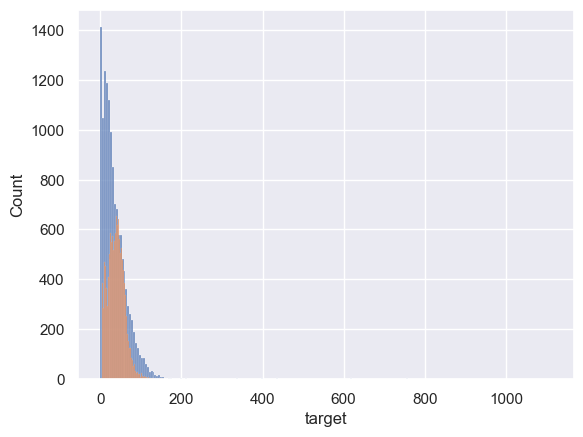

In [10]:
sns.histplot(y_train)
sns.histplot(model.predict(X_train))

<Axes: xlabel='target', ylabel='Count'>

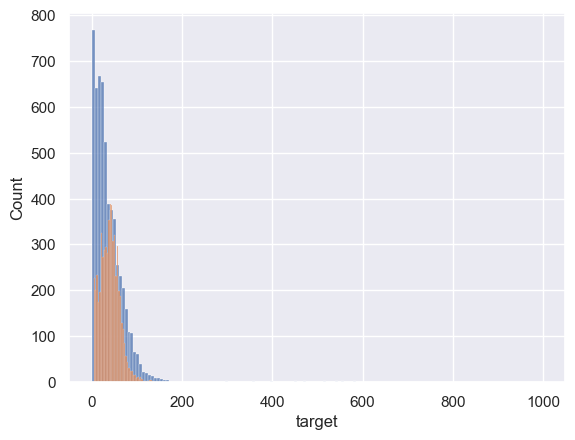

In [11]:
sns.histplot(y_test)
sns.histplot(model.predict(X_test))

<Axes: xlabel='target', ylabel='Count'>

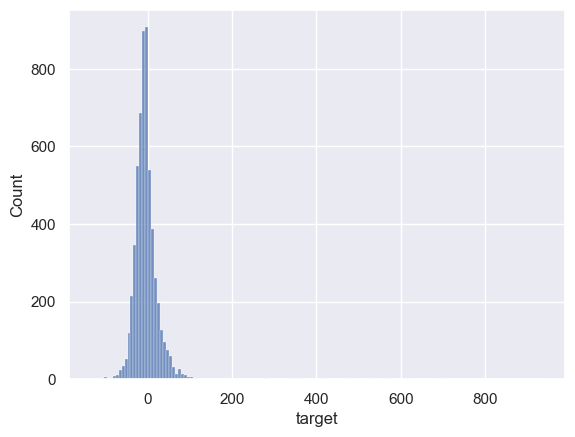

In [12]:
sns.histplot(y_test - model.predict(X_test))

### Shap

In [13]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

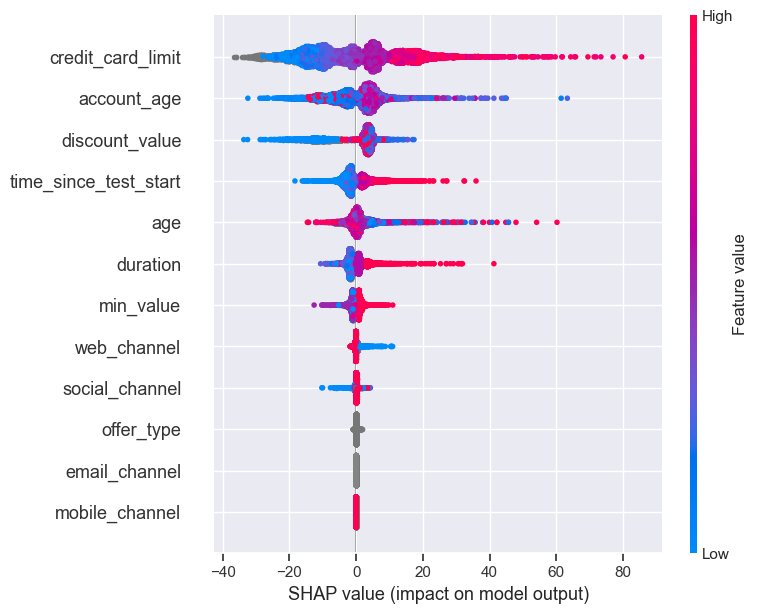

In [14]:
shap.summary_plot(shap_values, X_train)

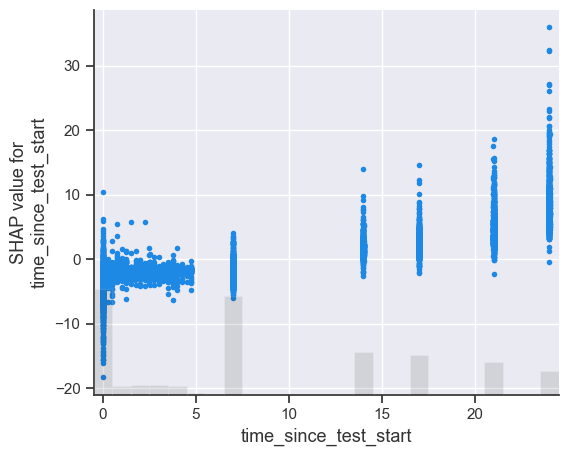

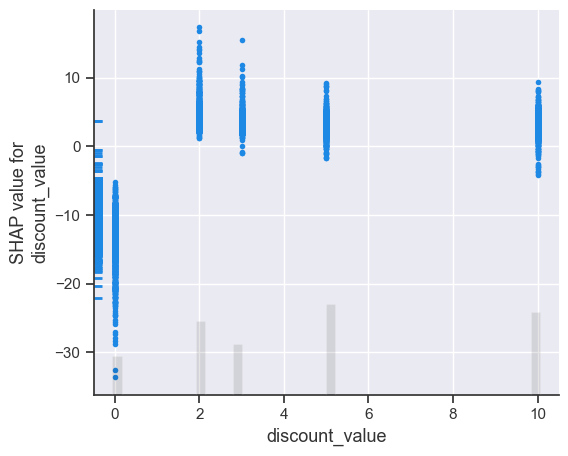

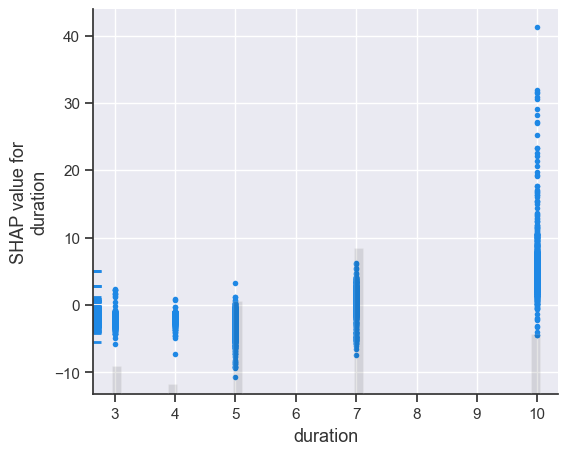

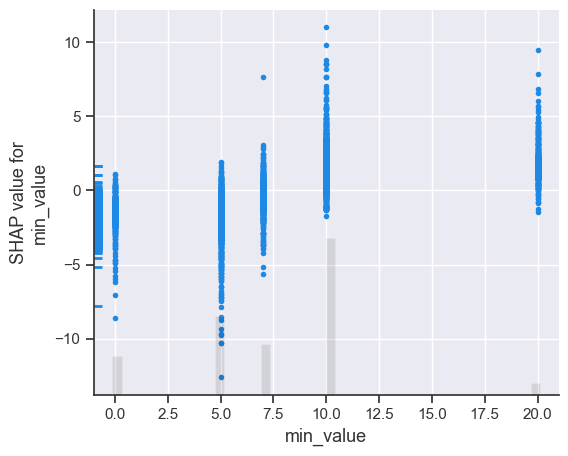

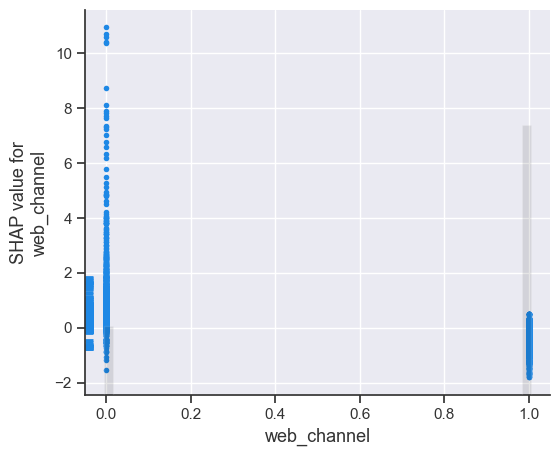

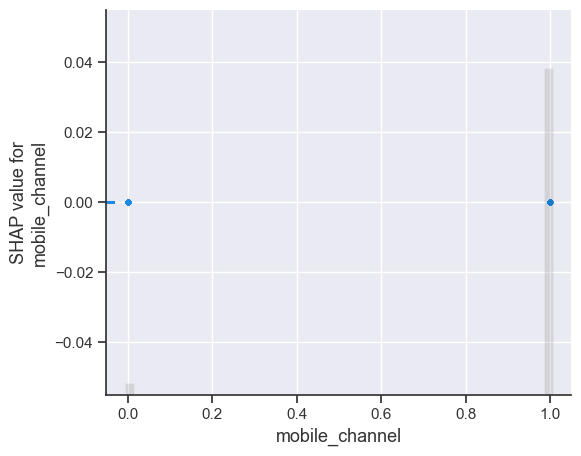

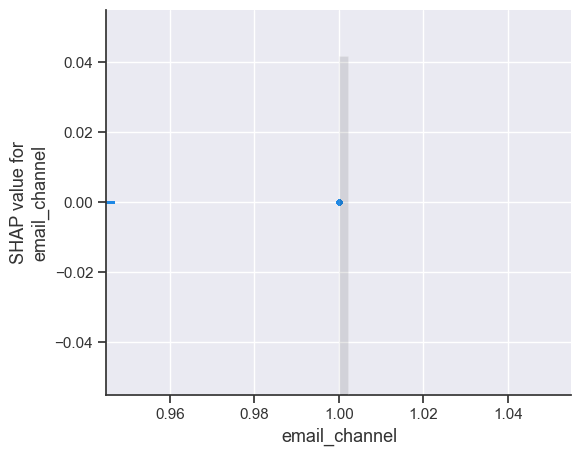

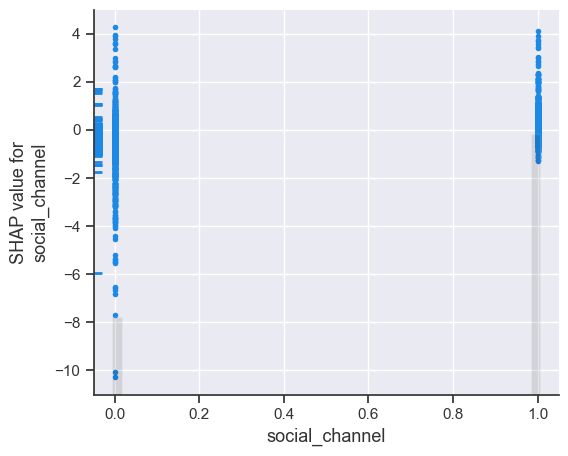

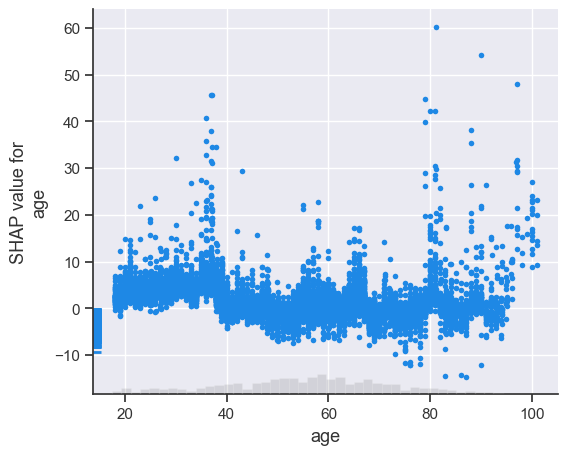

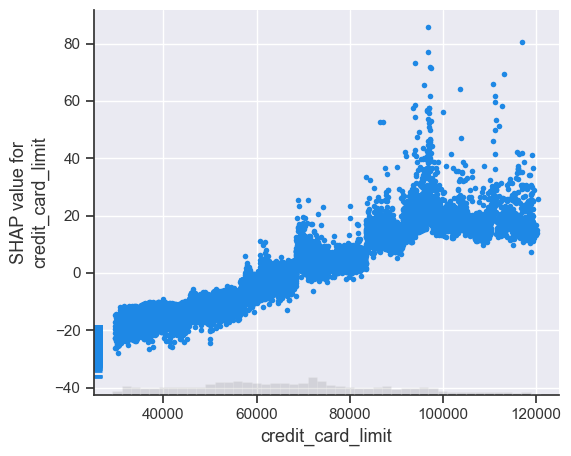

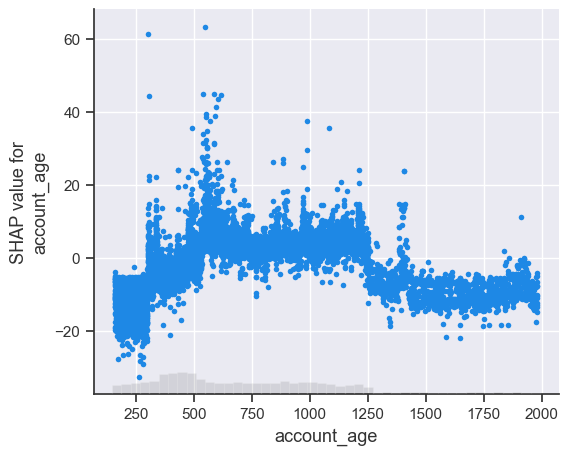

In [15]:
for name in X_train.columns:
    if name != "offer_type":
        shap.plots.scatter(shap_values[:, name])

## Results

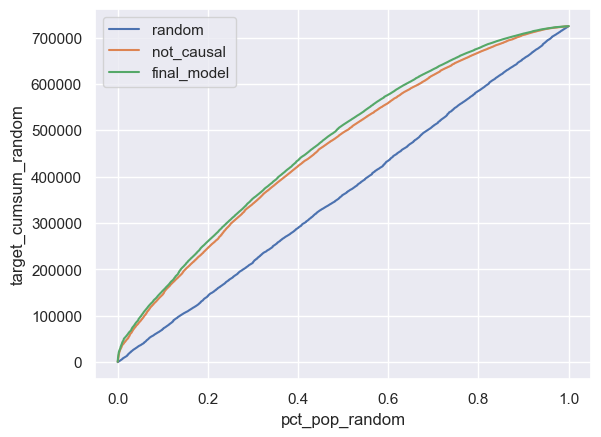

In [16]:
df = pd.read_parquet(str(Path.cwd().parent / 'data' / 'processed'/ 'unified'))
df = df[df['is_offer']].copy()
df['offer_type'] = df['offer_type'].fillna("None").astype("category")

df['prediction'] = model.predict(df[features])
df['prediction_not_causal'] = not_causal_model.predict(df[[
    "age",
    "credit_card_limit",
    "account_age",
]])

df["random_score"] = np.random.rand(len(df))

df["pct_pop_random"] = df["random_score"].rank(pct=True, ascending=False)
df["pct_pop_not_causal"] = df["prediction_not_causal"].rank(pct=True, ascending=False)
df["pct_pop_w_treatment"] = df['prediction'].rank(pct=True, ascending=False)

df = df.sort_values(by="random_score", ascending=False)
df["target_cumsum_random"] = df["target"].cumsum()

df = df.sort_values(by="prediction_not_causal", ascending=False)
df["target_cumsum_not_causal"] = df["target"].cumsum()

df = df.sort_values(by="prediction", ascending=False)
df["target_cumsum"] = df["target"].cumsum()
_, ax = plt.subplots()

sns.lineplot(data=df, x='pct_pop_random', y='target_cumsum_random', label='random', ax=ax)
sns.lineplot(data=df, x='pct_pop_not_causal', y='target_cumsum_not_causal', label='not_causal', ax=ax)
sns.lineplot(data=df, x='pct_pop_w_treatment', y='target_cumsum', label='final_model', ax=ax)

ax.legend()